# 04 — Modélisation & Comparaison des stratégies de rééquilibrage

**Phase 3 — Livrable 1**

Objectifs :
1. Entraîner 4 familles de modèles différentes
2. Comparer 3 stratégies de gestion du déséquilibre
3. Tableau comparatif des 12 configurations (F1 ± σ)
4. Sélectionner la meilleure combinaison modèle × stratégie

**Rappel métier** : Prédire l'inactivité de dépôts GitHub.
- Classe 1 = inactif (minoritaire, ~15%)
- Métrique principale : **Recall (classe 1)** ≥ 0.80
- Métrique de comparaison ici : **F1-score (classe 1)**

## 1. Setup et imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, make_scorer

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Tentative d'import XGBoost (plus performant que GradientBoosting sklearn)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost disponible ✓")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost non disponible — utilisation de GradientBoostingClassifier (sklearn)")

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print("Imports OK")

XGBoost non disponible — utilisation de GradientBoostingClassifier (sklearn)
Imports OK


---
## 2. Chargement des données prétraitées (Phase 2)

On charge directement les splits et le preprocessor produits par le notebook `03_preprocessing.ipynb`,
au lieu de reproduire le pipeline de preprocessing.

**Fichiers chargés :**
- `data/processed/train.csv`, `validation.csv`, `test.csv` — splits stratifiés (70/15/15)
- `models/preprocessor.joblib` — pipeline de preprocessing (fit sur le train)

In [16]:
# ── Chargement des splits produits par 03_preprocessing ──────────────────────
train_df = pd.read_csv('../data/processed/train.csv')
val_df   = pd.read_csv('../data/processed/validation.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

# Séparation X / y
X_train = train_df.drop(columns=['is_inactive'])
y_train = train_df['is_inactive']
X_val   = val_df.drop(columns=['is_inactive'])
y_val   = val_df['is_inactive']
X_test  = test_df.drop(columns=['is_inactive'])
y_test  = test_df['is_inactive']

print(f"Train      : {X_train.shape[0]} ({y_train.mean()*100:.2f}% inactifs)")
print(f"Validation : {X_val.shape[0]} ({y_val.mean()*100:.2f}% inactifs)")
print(f"Test       : {X_test.shape[0]} ({y_test.mean()*100:.2f}% inactifs)")

# Calcul du ratio de déséquilibre pour XGBoost
N_NEG = (y_train == 0).sum()
N_POS = (y_train == 1).sum()
SCALE_POS_WEIGHT = N_NEG / N_POS
print(f"\nClasse 0 (actif)   : {N_NEG}")
print(f"Classe 1 (inactif) : {N_POS}")
print(f"scale_pos_weight   : {SCALE_POS_WEIGHT:.2f}")

# ── Chargement du preprocessor entraîné ──────────────────────────────────────
preprocessor = joblib.load('../models/preprocessor.joblib')
print(f"\nPreprocessor chargé depuis models/preprocessor.joblib")

# ── Définition des colonnes par type ─────────────────────────────────────────
num_cols = ['stars', 'forks', 'open_issues', 'watchers', 'size_kb',
            'repo_age_days', 'contributor_count', 'avg_issue_response_hours',
            'engagement_rate', 'stars_forks_ratio',
            'activity_score', 'issues_per_contributor']
cat_cols = ['language', 'license', 'age_category']
bin_cols = ['has_description', 'has_homepage', 'has_wiki', 'has_projects', 'is_fork']

print(f"Colonnes : {len(num_cols)} num + {len(cat_cols)} cat + {len(bin_cols)} bin")
# ── Sous-pipelines pour la reconstruction dans ImbPipeline ────────────────────
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
print("Sous-pipelines num/cat reconstruits pour ImbPipeline")

Train      : 10500 (15.00% inactifs)
Validation : 2250 (15.02% inactifs)
Test       : 2250 (14.98% inactifs)

Classe 0 (actif)   : 8925
Classe 1 (inactif) : 1575
scale_pos_weight   : 5.67

Preprocessor chargé depuis models/preprocessor.joblib
Colonnes : 12 num + 3 cat + 5 bin
Sous-pipelines num/cat reconstruits pour ImbPipeline


---
## 3. Définition des 4 familles de modèles

| Modèle | Algorithme | Justification |
|--------|-----------|---------------|
| Logistic Regression | Linéaire | Baseline rapide et interprétable |
| Decision Tree | Arbre | Très interprétable, non-linéaire |
| Gradient Boosting | Boosting | Performance état de l'art sur données tabulaires |
| MLP | Réseau de neurones | Capture des interactions non-linéaires complexes |

In [17]:
# ─── Modèles pour stratégie class_weight ───────────────────────────────────────
lr_cw = LogisticRegression(
    class_weight='balanced', max_iter=5000, solver='lbfgs',
    random_state=RANDOM_STATE)

dt_cw = DecisionTreeClassifier(
    class_weight='balanced', random_state=RANDOM_STATE)

if XGB_AVAILABLE:
    gb_cw = XGBClassifier(
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=RANDOM_STATE, eval_metric='logloss',
        use_label_encoder=False)
    MODEL_NAME = 'Gradient Boosting (XGB)'
else:
    sample_weights = np.where(y_train == 1, SCALE_POS_WEIGHT, 1.0)
    gb_cw = GradientBoostingClassifier(random_state=RANDOM_STATE)
    MODEL_NAME = 'Gradient Boosting'

mlp_cw = MLPClassifier(
    hidden_layer_sizes=(100, 50), max_iter=500,
    random_state=RANDOM_STATE, early_stopping=True)

# ─── Modèles pour stratégies SMOTE / Undersampling (sans class_weight) ────────
lr_base = LogisticRegression(
    max_iter=5000, solver='lbfgs', random_state=RANDOM_STATE)

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)

if XGB_AVAILABLE:
    gb_base = XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss',
        use_label_encoder=False)
else:
    gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

mlp_base = MLPClassifier(
    hidden_layer_sizes=(100, 50), max_iter=500,
    random_state=RANDOM_STATE, early_stopping=True)

print(f"Modèle Gradient Boosting : {MODEL_NAME}")
print(f"scale_pos_weight : {SCALE_POS_WEIGHT:.2f}")
print("4 familles de modèles definies (class_weight + base)")

Modèle Gradient Boosting : Gradient Boosting
scale_pos_weight : 5.67
4 familles de modèles definies (class_weight + base)


---
## 4. Validation croisée — 12 configurations

**Protocole :**
- StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
- Métrique : F1-score sur la classe 1 (inactif)
- Le sampler est intégré dans le pipeline ImbLearn (appliqué uniquement sur le fold train)

**Justification** : La CV stratifiée préserve le ratio de déséquilibre dans chaque fold.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score, pos_label=1)
results = {}

# ─── Stratégie 1 : class_weight ────────────────────────────────────────────────
print("=" * 60)
print("Stratégie 1 : class_weight")
print("=" * 60)

configs_cw = [
    ('Logistic Regression', lr_cw),
    ('Decision Tree',       dt_cw),
    (MODEL_NAME,            gb_cw),
    ('MLP',                 mlp_cw)
]

for model_name, model in configs_cw:
    pipe = ImbPipeline([
        ('preprocessor', ColumnTransformer([
            ('num', num_pipeline, num_cols),
            ('cat', cat_pipeline, cat_cols),
            ('bin', 'passthrough', bin_cols)
        ], remainder='drop')),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring=f1_scorer, n_jobs=-1)
    results[(model_name, 'class_weight')] = scores
    print(f"  {model_name:25s} | F1 = {scores.mean():.4f} ± {scores.std():.4f}")

print()

# ─── Stratégie 2 : SMOTE ───────────────────────────────────────────────────────
print("=" * 60)
print("Stratégie 2 : SMOTE")
print("=" * 60)

configs_base = [
    ('Logistic Regression', lr_base),
    ('Decision Tree',       dt_base),
    (MODEL_NAME,            gb_base),
    ('MLP',                 mlp_base)
]

for model_name, model in configs_base:
    pipe = ImbPipeline([
        ('preprocessor', ColumnTransformer([
            ('num', num_pipeline, num_cols),
            ('cat', cat_pipeline, cat_cols),
            ('bin', 'passthrough', bin_cols)
        ], remainder='drop')),
        ('sampler', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring=f1_scorer, n_jobs=-1)
    results[(model_name, 'SMOTE')] = scores
    print(f"  {model_name:25s} | F1 = {scores.mean():.4f} ± {scores.std():.4f}")

print()

# ─── Stratégie 3 : Undersampling ───────────────────────────────────────────────
print("=" * 60)
print("Stratégie 3 : RandomUnderSampler")
print("=" * 60)

for model_name, model in configs_base:
    pipe = ImbPipeline([
        ('preprocessor', ColumnTransformer([
            ('num', num_pipeline, num_cols),
            ('cat', cat_pipeline, cat_cols),
            ('bin', 'passthrough', bin_cols)
        ], remainder='drop')),
        ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring=f1_scorer, n_jobs=-1)
    results[(model_name, 'Undersampling')] = scores
    print(f"  {model_name:25s} | F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Stratégie 1 : class_weight
  Logistic Regression       | F1 = 0.7155 ± 0.0087
  Decision Tree             | F1 = 0.7185 ± 0.0069
  Gradient Boosting         | F1 = 0.8079 ± 0.0202
  MLP                       | F1 = 0.7480 ± 0.0178

Stratégie 2 : SMOTE
  Logistic Regression       | F1 = 0.7245 ± 0.0064
  Decision Tree             | F1 = 0.7144 ± 0.0103
  Gradient Boosting         | F1 = 0.7997 ± 0.0134
  MLP                       | F1 = 0.7271 ± 0.0128

Stratégie 3 : RandomUnderSampler
  Logistic Regression       | F1 = 0.7063 ± 0.0149
  Decision Tree             | F1 = 0.6843 ± 0.0105
  Gradient Boosting         | F1 = 0.7610 ± 0.0131
  MLP                       | F1 = 0.6778 ± 0.0221


---
## 5. Tableau comparatif — 12 configurations

In [19]:
models_order = ['Logistic Regression', 'Decision Tree', MODEL_NAME, 'MLP']
strategies_order = ['class_weight', 'SMOTE', 'Undersampling']

rows = []
for model_name in models_order:
    row = {'Modèle': model_name}
    for strat in strategies_order:
        s = results[(model_name, strat)]
        row[strat] = f"{s.mean():.4f} ± {s.std():.4f}"
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Modèle')
print("\n=== TABLEAU COMPARATIF : F1-score (classe 1) ± σ ===")
print(results_df.to_string())

# Trouver la meilleure configuration
best_mean = 0
best_config = None
for (model_name, strat), scores in results.items():
    if scores.mean() > best_mean:
        best_mean = scores.mean()
        best_std  = scores.std()
        best_config = (model_name, strat)

print(f"\n>>> MEILLEURE CONFIGURATION : {best_config[0]} + {best_config[1]}")
print(f"    F1 = {best_mean:.4f} ± {best_std:.4f}")


=== TABLEAU COMPARATIF : F1-score (classe 1) ± σ ===
                        class_weight            SMOTE    Undersampling
Modèle                                                                
Logistic Regression  0.7155 ± 0.0087  0.7245 ± 0.0064  0.7063 ± 0.0149
Decision Tree        0.7185 ± 0.0069  0.7144 ± 0.0103  0.6843 ± 0.0105
Gradient Boosting    0.8079 ± 0.0202  0.7997 ± 0.0134  0.7610 ± 0.0131
MLP                  0.7480 ± 0.0178  0.7271 ± 0.0128  0.6778 ± 0.0221

>>> MEILLEURE CONFIGURATION : Gradient Boosting + class_weight
    F1 = 0.8079 ± 0.0202


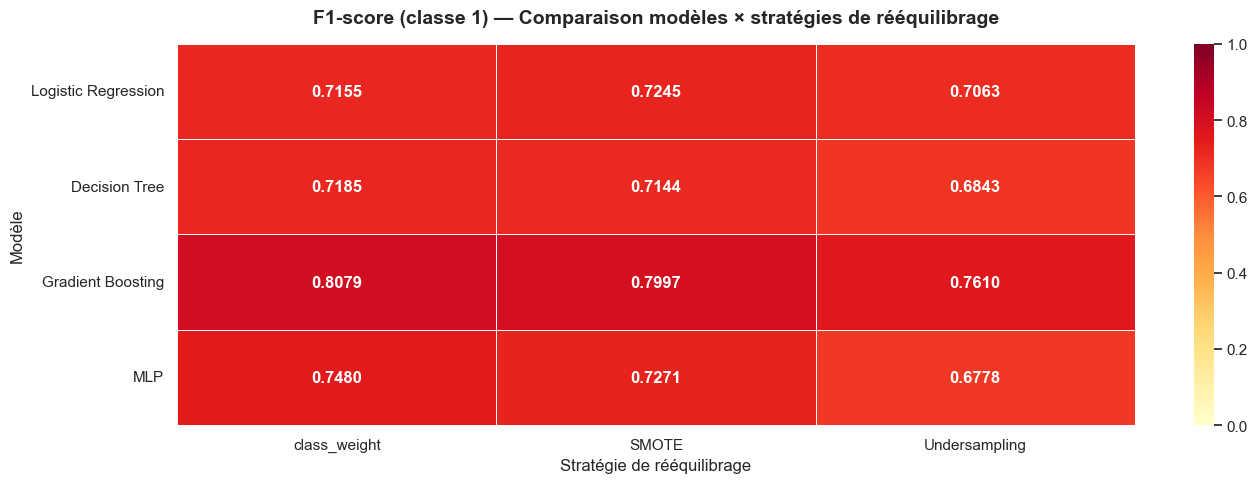

Heatmap sauvegardée → data/modeling_heatmap.png


In [20]:
# Heatmap des F1 scores
fig, ax = plt.subplots(figsize=(14, 5))

heatmap_data = np.zeros((len(models_order), len(strategies_order)))
for i, model_name in enumerate(models_order):
    for j, strat in enumerate(strategies_order):
        heatmap_data[i, j] = results[(model_name, strat)].mean()

heatmap_df = pd.DataFrame(heatmap_data, index=models_order, columns=strategies_order)

sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('F1-score (classe 1) — Comparaison modèles × stratégies de rééquilibrage',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stratégie de rééquilibrage', fontsize=12)
ax.set_ylabel('Modèle', fontsize=12)
plt.tight_layout()
plt.savefig('../data/modeling_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap sauvegardée → data/modeling_heatmap.png")

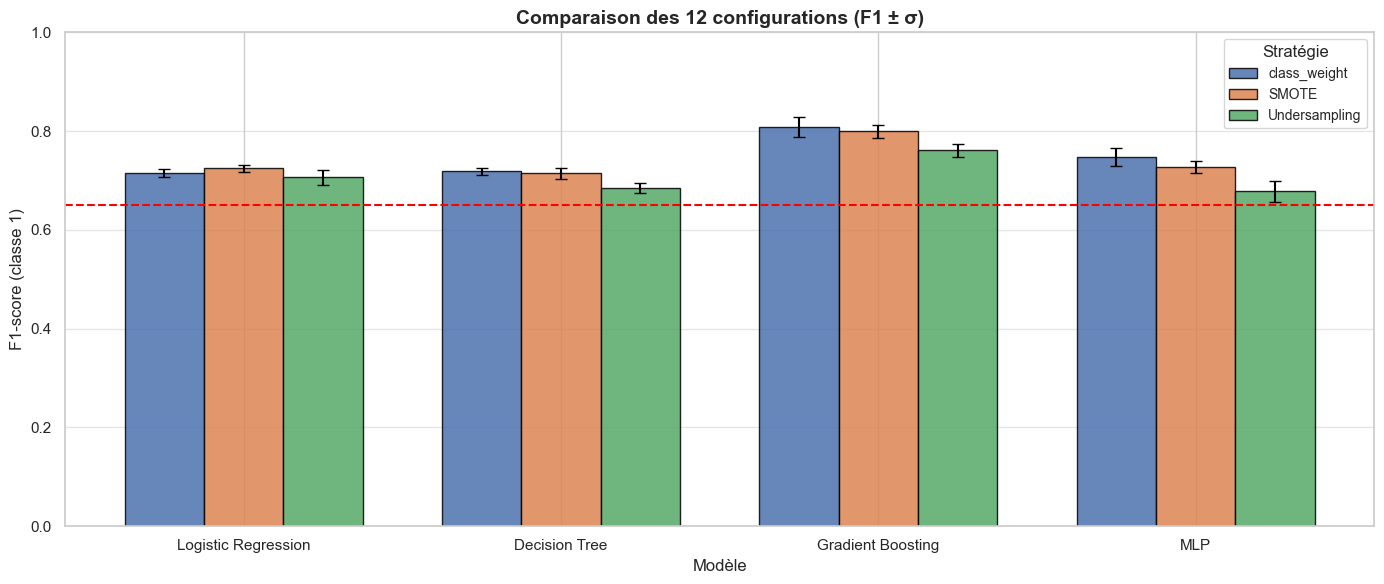

In [21]:
# Graphique en barres avec barres d'erreur
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(models_order))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for j, (strat, color) in enumerate(zip(strategies_order, colors)):
    means = [results[(m, strat)].mean() for m in models_order]
    stds  = [results[(m, strat)].std()  for m in models_order]
    ax.bar(x + j * width, means, width, label=strat, color=color,
           alpha=0.85, edgecolor='black')
    ax.errorbar(x + j * width, means, yerr=stds, fmt='none',
                ecolor='black', capsize=4, linewidth=1.5)

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('F1-score (classe 1)', fontsize=12)
ax.set_title('Comparaison des 12 configurations (F1 ± σ)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_order, fontsize=11)
ax.legend(title='Stratégie', fontsize=10)
ax.set_ylim(0, 1)
ax.axhline(y=0.65, color='red', linestyle='--', linewidth=1.5, label='Seuil cible F1 = 0.65')
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/modeling_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Évaluation complémentaire sur le jeu de validation

Pour la meilleure configuration, calculer Recall, Precision, F1 sur val.

Évaluation sur validation : Gradient Boosting + class_weight
--------------------------------------------------
              precision    recall  f1-score   support

   Actif (0)       0.96      0.97      0.97      1912
 Inactif (1)       0.84      0.79      0.81       338

    accuracy                           0.94      2250
   macro avg       0.90      0.88      0.89      2250
weighted avg       0.94      0.94      0.94      2250



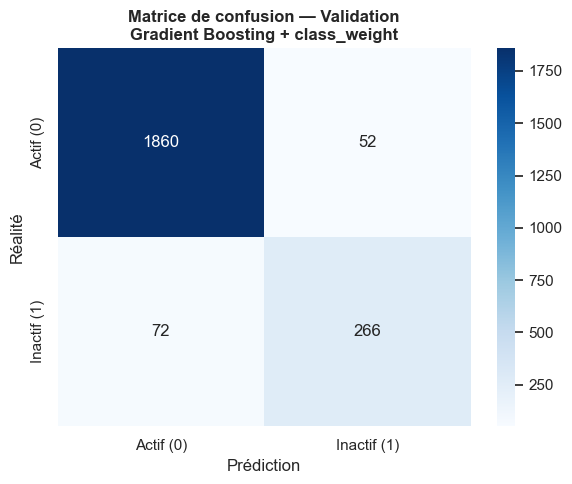

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

best_model_name, best_strategy = best_config
print(f"Évaluation sur validation : {best_model_name} + {best_strategy}")
print("-" * 50)

# Reconstruire le meilleur pipeline
if best_strategy == 'class_weight':
    best_clf = dict(configs_cw)[best_model_name]
    sampler_step = []
else:
    best_clf = dict(configs_base)[best_model_name]
    if best_strategy == 'SMOTE':
        sampler_step = [('sampler', SMOTE(random_state=RANDOM_STATE))]
    else:
        sampler_step = [('sampler', RandomUnderSampler(random_state=RANDOM_STATE))]

best_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
    ('bin', 'passthrough', bin_cols)
], remainder='drop')

best_pipeline = ImbPipeline(
    [('preprocessor', best_preprocessor)] + sampler_step + [('classifier', best_clf)])

best_pipeline.fit(X_train, y_train)
y_pred_val = best_pipeline.predict(X_val)

print(classification_report(y_val, y_pred_val,
                              target_names=['Actif (0)', 'Inactif (1)']))

cm = confusion_matrix(y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Actif (0)', 'Inactif (1)'],
            yticklabels=['Actif (0)', 'Inactif (1)'])
ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Réalité', fontsize=12)
ax.set_title(f'Matrice de confusion — Validation\n{best_model_name} + {best_strategy}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Sauvegarde des résultats

In [23]:
import json

# Sauvegarde du meilleur pipeline (non tuné) pour référence
joblib.dump(best_pipeline, '../models/best_pipeline_before_tuning.joblib')

# Sauvegarde des résultats de CV
results_summary = {
    'best_model': best_model_name,
    'best_strategy': best_strategy,
    'best_f1_mean': float(best_mean),
    'best_f1_std': float(best_std),
    'scale_pos_weight': float(SCALE_POS_WEIGHT),
    'xgb_available': XGB_AVAILABLE,
    'model_name_used': MODEL_NAME,
    'cv_results': {
        str(k): {'mean': float(v.mean()), 'std': float(v.std()), 'scores': v.tolist()}
        for k, v in results.items()
    }
}

with open('../models/modeling_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print("Résultats sauvegardés :")
print("  models/best_pipeline_before_tuning.joblib")
print("  models/modeling_results.json")
print()
print("=" * 60)
print(f"CONCLUSION : Meilleure combinaison identifiée")
print(f"  Modèle    : {best_model_name}")
print(f"  Stratégie : {best_strategy}")
print(f"  F1 (CV)   : {best_mean:.4f} ± {best_std:.4f}")
print()
print("→ Cette combinaison sera optimisée dans notebook 05_tuning.ipynb")


Résultats sauvegardés :
  models/best_pipeline_before_tuning.joblib
  models/modeling_results.json

CONCLUSION : Meilleure combinaison identifiée
  Modèle    : Gradient Boosting
  Stratégie : class_weight
  F1 (CV)   : 0.8079 ± 0.0202

→ Cette combinaison sera optimisée dans notebook 05_tuning.ipynb
